# NeuroRAG Ablation Study on PubMed Summary QA

This notebook allows you to disable (ablate) almost any component of the NeuroRAG pipeline and evaluate the effect on text-to-text metrics (Cosine Similarity, BLEU, ROUGE-1, ROUGE-L, FActScore, BERTScore) using the first 50 questions of `pubmed_summary_qa.csv`.

In [1]:
import sys
sys.path.append('..')
sys.path.append('../neurorag')
sys.path.append('../neurorag/chains')

import os
import time
import json
import pandas as pd
from tqdm import tqdm
from pathlib import Path
from dotenv import load_dotenv
from getpass import getpass

from neurorag.neurorag import NeuroRAG

from metrics import (
  embeddings_cosine_sim_metric,
  bleu_metric,
  rogue_l_metric,
  rogue_1_metric,
  factscore_metric,
  bert_score_metric,
)

## Disable warnings

In [2]:
import warnings
warnings.filterwarnings('ignore')

## Setup environment variables

You have to define the following environment variables in the `.env` file, terminal environment, or input field within this Jupyter notebook:
1. TAVILY_API_KEY
2. ENTREZ_EMAIL
3. OPENROUTER_API_KEY
4. CHROMA_API_KEY
5. CHROMA_TENANT
6. CHROMA_DATABASE
7. CHROMA_COLLECTION_NAME

In [3]:
env_variables = [
  'TAVILY_API_KEY',
  'ENTREZ_EMAIL',
  'OPENROUTER_API_KEY',
  'CHROMA_API_KEY',
  'CHROMA_TENANT',
  'CHROMA_DATABASE',
  'CHROMA_COLLECTION_NAME',
]

load_dotenv()

for key in env_variables:
  value = os.getenv(key)

  if value is None:
    value = getpass(key)

  os.environ[key] = value

## Ablation Config
Set any component to False to disable it in the pipeline.

In [4]:
ablation_config: dict[str, bool] = {
    'step_back': True,
    'decomposition': True,
    'hyde': True,
    'vector_store': True,
    'pubmed': True,
    'arxiv': True,
    'ncbi_protein': True,
    'ncbi_gene': True,
    'biorxiv': True,
    'medrxiv': True,
    'document_grading': True,
    'hallucination_grading': True,
    'answer_grading': True,
    'web_search': True,
}


## NeuroRAG Wrapper for Ablation
This class disables components according to the config above.

In [5]:
class NeuroRAGAblation(NeuroRAG):
    def __init__(self, ablation_config, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.ablation_config = ablation_config

    def generate_step_back_query_node(self, state):
        if not self.ablation_config.get('step_back', True):
            return {'step_back_query': state['query']}
        return super().generate_step_back_query_node(state)

    def generate_subqueries_node(self, state):
        if not self.ablation_config.get('decomposition', True):
            return {'subqueries': []}
        return super().generate_subqueries_node(state)

    def generate_hyde_documents_node(self, state):
        if not self.ablation_config.get('hyde', True):
            return {'generated_documents': [state['query']]}
        return super().generate_hyde_documents_node(state)

    def vector_store_retriever_node(self, state):
        if not self.ablation_config.get('vector_store', True):
            return {'documents': []}
        return super().vector_store_retriever_node(state)

    def pub_med_retriever_node(self, state):
        if not self.ablation_config.get('pubmed', True):
            return {'documents': []}
        return super().pub_med_retriever_node(state)

    def arxiv_retriever_node(self, state):
        if not self.ablation_config.get('arxiv', True):
            return {'documents': []}
        return super().arxiv_retriever_node(state)

    def ncbi_protein_db_retriever_node(self, state):
        if not self.ablation_config.get('ncbi_protein', True):
            return {'documents': []}
        return super().ncbi_protein_db_retriever_node(state)

    def ncbi_gene_db_retriever_node(self, state):
        if not self.ablation_config.get('ncbi_gene', True):
            return {'documents': []}
        return super().ncbi_gene_db_retriever_node(state)

    def biorxiv_retriever_node(self, state):
        if not self.ablation_config.get('biorxiv', True):
            return {'documents': []}
        return super().biorxiv_retriever_node(state)

    def medrxiv_retriever_node(self, state):
        if not self.ablation_config.get('medrxiv', True):
            return {'documents': []}
        return super().medrxiv_retriever_node(state)

    def grade_documents_node(self, state):
        if not self.ablation_config.get('document_grading', True):
            docs = state['documents']
            unique = list({d.page_content: d for d in docs}.values())
            state['documents'].clear()
            return {'documents': unique[:5], 'web_search': False}
        return super().grade_documents_node(state)

    def grade_generation_node(self, state):
        generations_number = state['generations_number']

        if generations_number >= self.max_retries:
            return 'useful'

        if not self.ablation_config.get('hallucination_grading', True) and not self.ablation_config.get('answer_grading', True):
            return 'useful'
        if not self.ablation_config.get('hallucination_grading', True):
            # Only answer grading
            query = state['query']
            generation = state['generation']
            try:
                grade = self.answer_grade_chain.invoke(query, generation)
            except Exception:
                grade = 'no'
            return 'useful' if grade == 'yes' else 'not useful'
        if not self.ablation_config.get('answer_grading', True):
            # Only hallucination grading
            documents = state['documents']
            generation = state['generation']
            try:
                context = (
                    '\n\n' + '\n\n'.join(map(lambda doc: doc.page_content, documents)) + '\n\n'
                )
                grade = self.hallucinations_chain.invoke(generation, context)
            except Exception:
                grade = 'no'
            return 'useful' if grade == 'yes' else 'not useful'
        return super().grade_generation_node(state)

    def web_search_node(self, state):
        if not self.ablation_config.get('web_search', True):
            return {'documents': [], 'web_results': []}
        return super().web_search_node(state)


## Setup evaluation

### Load cache

In [6]:
try:
  with open('cache.json', 'r') as file:
    cache = json.load(file)
except FileNotFoundError:
  cache = {}



### Load PubMed Summary QA dataset

In [7]:
NUM_QUESTIONS = 50
ANSWER_STYLE = 'Answer in 2-3 sentences (30-50 words). Use plain, accessible language like a medical textbook — avoid technical jargon and specific brain region names unless the question asks for them. Explain the concept clearly, as in a PubMed summary.'

mediqa_df = pd.read_csv('../datasets/pubmed_summary_qa.csv')[:NUM_QUESTIONS]
questions = list(mediqa_df['question'].tolist())
expected_answers = list(mediqa_df['answer'].tolist())

print(f'Loaded {len(questions)} questions from pubmed_summary_qa.csv')
mediqa_df

Loaded 50 questions from pubmed_summary_qa.csv


,question,answer
0,Which brain region is involved in working memo...,The dorsolateral prefrontal cortex (DLPFC) is ...
1,Are other brain regions also involved in worki...,"Yes, other brain regions, such as the premotor..."
2,What is a visuomotor task?,A visuomotor task is a type of task that requi...
3,What brain regions are involved in visuomotor ...,The brain regions involved in visuomotor trans...
4,What is the role of the prefrontal cortex in v...,The prefrontal cortex is involved in the prepa...
5,How does the auditory system respond to differ...,The auditory system's response to sound varies...
6,What is tonotopic organization in the auditory...,Tonotopic organization refers to the mapping o...
7,What brain regions are involved in language pr...,Language processing involves areas in the pref...
8,How does bilingualism affect language processi...,Bilingualism is associated with overlapping ac...
9,What is functional magnetic resonance imaging ...,Functional magnetic resonance imaging (fMRI) i...


### Evaluation helpers

In [8]:
import time

def invoke_with_retries(app, question, k = 10, sleep: int = 5):
    for i in range(k):
        try:
            return app.invoke(question)
        except Exception as e:
            if i == k - 1:
                raise e
            else:
                print(e)
            time.sleep(sleep * i)

In [9]:
def compute_metrics(expected: list[str], predicted: list[str]) -> dict:
  return {
    'cos_sim': embeddings_cosine_sim_metric(expected, predicted),
    'bleu': bleu_metric(expected, predicted),
    'rouge_1': rogue_1_metric(expected, predicted),
    'rouge_l': rogue_l_metric(expected, predicted),
    'factscore': factscore_metric(expected, predicted),
    'bert_score': bert_score_metric(expected, predicted),
  }

In [10]:
CACHE_KEY_PREFIX = 'ablation_pubmed_qa'

def eval_rag_pubmed(app, experiment_name: str) -> dict:
    cache_key = f'{CACHE_KEY_PREFIX}_{experiment_name}'

    if cache_key not in cache:
        cache[cache_key] = {}

    predicted_answers = []
    generation_times = []

    for question in tqdm(questions, desc=experiment_name):
        if question not in cache[cache_key]:
            start_time = time.perf_counter()
            result = invoke_with_retries(app, question)
            elapsed = time.perf_counter() - start_time
            generation_times.append(elapsed)
            cache[cache_key][question] = result['generation']

            with open('cache.json', 'w') as f:
                json.dump(cache, f)

        predicted_answers.append(cache[cache_key][question])

    if generation_times:
        print(f'  Generation times (n={len(generation_times)}): '
              f'mean={sum(generation_times)/len(generation_times):.1f}s, '
              f'total={sum(generation_times):.1f}s')
    else:
        print('  All answers loaded from cache.')

    metrics = compute_metrics(expected_answers, predicted_answers)
    return metrics

## Run Ablation Study
Evaluate different ablation settings on PubMed Summary QA using text-to-text metrics.

In [ ]:
ablation_settings = [
    ('All enabled', ablation_config.copy()),
    # ('No step_back', {**ablation_config, 'step_back': False}),
    # ('No decomposition', {**ablation_config, 'decomposition': False}),
    # ('No hyde', {**ablation_config, 'hyde': False}),
    # ('No document_grading', {**ablation_config, 'document_grading': False}),
    # ('No hallucination_grading', {**ablation_config, 'hallucination_grading': False}),
    # ('No answer_grading', {**ablation_config, 'answer_grading': False}),
    # ('No web_search', {**ablation_config, 'web_search': False}),
    # ('No retrievers', {**ablation_config, 'vector_store': False, 'pubmed': False, 'arxiv': False, 'ncbi_gene': False, 'ncbi_protein': False, 'biorxiv': False, 'medrxiv': False}),
]

METRIC_NAMES = ['cos_sim', 'bleu', 'rouge_1', 'rouge_l', 'factscore', 'bert_score']

results = []
for name, config in ablation_settings:
    print(f'\n=== Running: {name} ===')
    app = NeuroRAGAblation(config, debug=False, answer_style=ANSWER_STYLE)
    app.compile()

    metrics = eval_rag_pubmed(app, name)
    row = {'experiment_name': name, **metrics}
    results.append(row)

    for k, v in metrics.items():
        print(f'  {k}: {v:.4f}')

results_df = pd.DataFrame(results)
print('\n=== Results Summary ===')
print(results_df.to_string(index=False))


=== Running: All enabled ===


All enabled:   0%|          | 0/50 [00:00<?, ?it/s]

Too Many Requests, waiting for 0.20 seconds...
Too Many Requests, waiting for 0.20 seconds...
Too Many Requests, waiting for 0.40 seconds...
Too Many Requests, waiting for 1.60 seconds...
Too Many Requests, waiting for 1.60 seconds...
Too Many Requests, waiting for 1.60 seconds...
Too Many Requests, waiting for 12.80 seconds...
Too Many Requests, waiting for 12.80 seconds...


All enabled:   2%|▏         | 1/50 [00:36<29:26, 36.05s/it]

Too Many Requests, waiting for 51.20 seconds...
Too Many Requests, waiting for 51.20 seconds...
Too Many Requests, waiting for 204.80 seconds...


...

Too Many Requests, waiting for 3276.80 seconds...
Too Many Requests, waiting for 3276.80 seconds...
Too Many Requests, waiting for 3276.80 seconds...


All enabled:  70%|███████   | 35/50 [52:08<29:28, 117.93s/it]

Too Many Requests, waiting for 3276.80 seconds...
Too Many Requests, waiting for 3276.80 seconds...
Too Many Requests, waiting for 3276.80 seconds...


All enabled:  80%|████████  | 40/50 [55:28<06:52, 41.24s/it] 

Too Many Requests, waiting for 3276.80 seconds...
Too Many Requests, waiting for 3276.80 seconds...


In [ ]:
results_df.to_csv('pubmed_ablation_results.csv', index=False)
print('Results saved to pubmed_ablation_results.csv')

print('\n=== Detailed Results ===')
for _, row in results_df.iterrows():
    print(f"\n{row['experiment_name']}:")
    for m in METRIC_NAMES:
        print(f'  {m}: {row[m]:.4f}')


Results saved to pubmed_ablation_results.csv

=== Detailed Results ===

All enabled:
  cos_sim: 0.7620
  bleu: 0.0640
  rouge_1: 0.3455
  rouge_l: 0.2756
  factscore: 0.2523
  bert_score: 0.3765


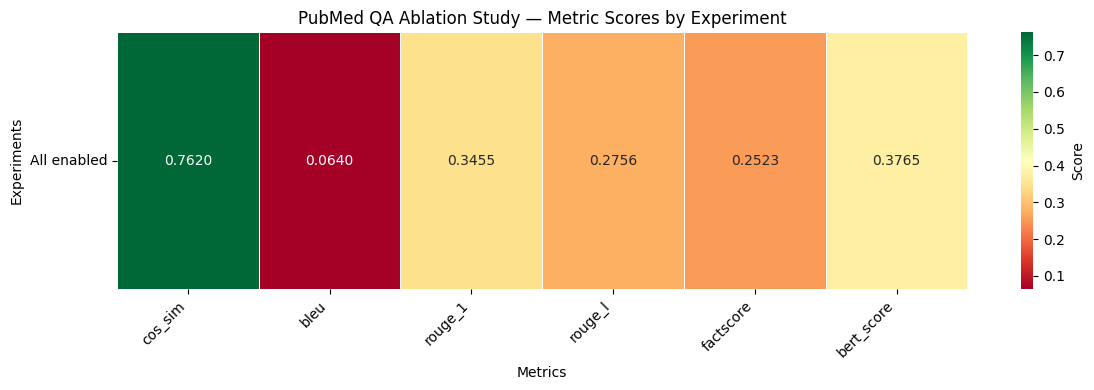

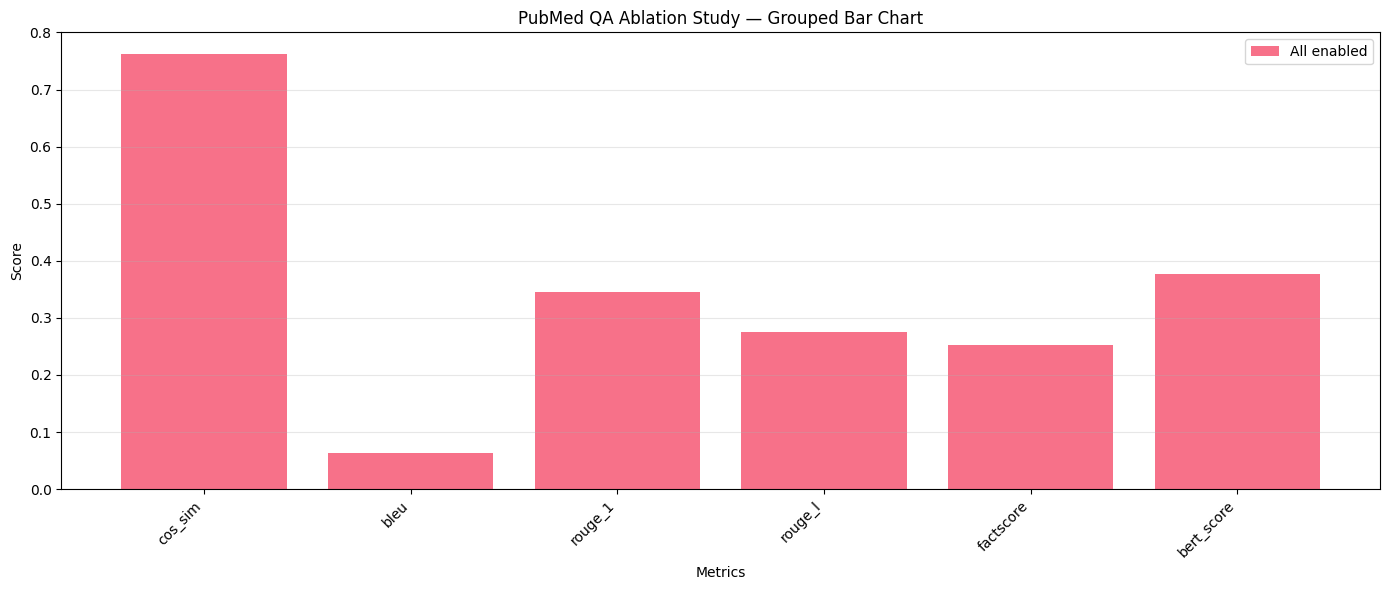

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('default')
sns.set_palette('husl')

heatmap_data = results_df.set_index('experiment_name')[METRIC_NAMES]

plt.figure(figsize=(12, max(4, len(results_df) * 1.2)))
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='RdYlGn',
            cbar_kws={'label': 'Score'}, linewidths=0.5)
plt.title('PubMed QA Ablation Study — Metric Scores by Experiment')
plt.xlabel('Metrics')
plt.ylabel('Experiments')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

n_metrics = len(METRIC_NAMES)
n_experiments = len(results_df)
x = np.arange(n_metrics)
width = 0.8 / n_experiments

fig, ax = plt.subplots(figsize=(14, 6))
for i, (_, row) in enumerate(results_df.iterrows()):
    values = [row[m] for m in METRIC_NAMES]
    ax.bar(x + i * width, values, width, label=row['experiment_name'])

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('PubMed QA Ablation Study — Grouped Bar Chart')
ax.set_xticks(x + width * (n_experiments - 1) / 2)
ax.set_xticklabels(METRIC_NAMES, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
